Word2Vec - векторное представление слов. Вход - текстовый корпус - векторизация встречамости - создание словаря. Векторы используются в ML. 
CBOW - алгоритм обучения в W2v. Предсказывание слова при данном контексте (цель – описание парадигматических отношений)
Skip-Gram - предсказание контекста при данном слове.

In [27]:
import gensim

# текст уже лемматизирован и токенизиован
f = 'skazkilem.txt'
data = gensim.models.word2vec.LineSentence(f) #генератор

# обучаем CBOW
model_CBOW = gensim.models.Word2Vec(data, vector_size=500, window=5, min_count=2, sg=0) # размерность вектора, окно в n слов, исклчение редких слов (меньше  2 раз)
model_CBOW.save('cbow_skazkilem.model')

# Перечитываем для Skip-Gram
data = gensim.models.word2vec.LineSentence(f)
model_sg = gensim.models.Word2Vec(data, vector_size=500, window=5, min_count=2, sg=1)
model_sg.save('skipgram_skazkilem.model')

In [28]:
from gensim.models import Word2Vec

cbow = Word2Vec.load('cbow_skazkilem.model')
sg = Word2Vec.load('skipgram_skazkilem.model')

# Пример: косинусное сходство
print('CBOW similarity:', cbow.wv.similarity("батрак", "работник"))
print('Skip-Gram similarity:', sg.wv.similarity("пётр", "царь"))

# Пример: топ-10 ближайших слов
print('CBOW most similar:', cbow.wv.most_similar("батрак", topn=10))
print('Skip-Gram most similar:', sg.wv.most_similar("батрак", topn=10))

CBOW similarity: 0.9922006
Skip-Gram similarity: 0.41455325
CBOW most similar: [('мальчик', 0.9990636706352234), ('стрелец', 0.9990197420120239), ('вынести', 0.9987220764160156), ('лиса', 0.9987157583236694), ('собираться', 0.9986447095870972), ('образ', 0.9983847737312317), ('приказчик', 0.998336672782898), ('младенец', 0.9983229637145996), ('василиса', 0.9983175992965698), ('взойти', 0.9981509447097778)]
Skip-Gram most similar: [('журавль', 0.9680848717689514), ('попадья', 0.964633584022522), ('рынок,', 0.9515609741210938), ('невестка', 0.9509442448616028), ('хозяйка', 0.9506909847259521), ('шут', 0.9503256678581238), ('дядя', 0.9498324990272522), ('богом!»', 0.9485187530517578), ('дьякон', 0.9472431540489197), ('данило', 0.9410055875778198)]


Визуализация векторов слов с помощью t-SNE

/Users/sergey/PycharmProjects/SemAnalyzer/.venvNew/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/Users/sergey/PycharmProjects/SemAnalyzer/.venvNew/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


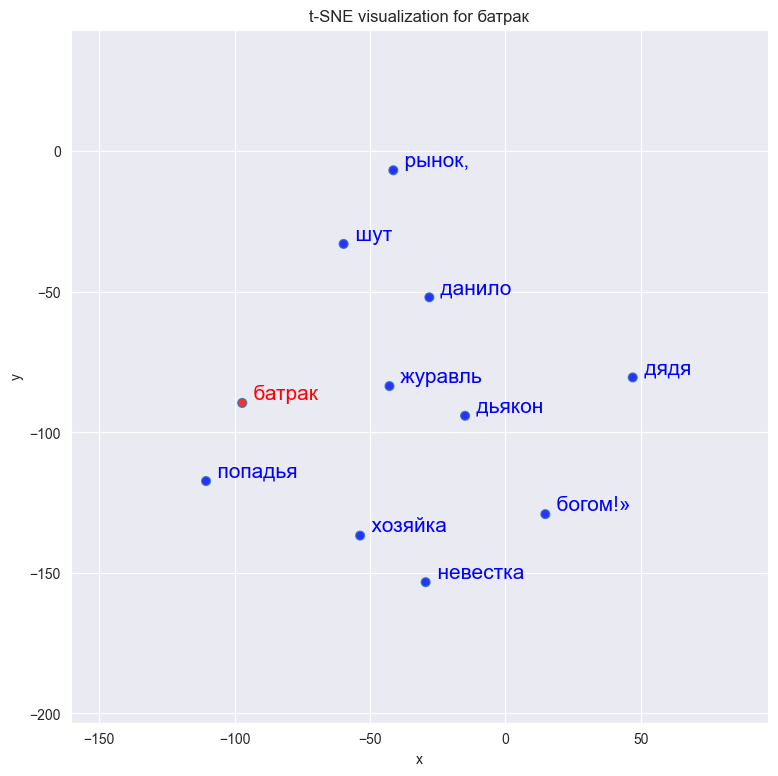

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_style("darkgrid")

def tsnescatterplot(model, word, list_names):
    #Визуализация целевого слова и его ближайших соседей
    arrays = np.empty((0, model.vector_size), dtype='f')
    word_labels = [word]
    color_list = ['red']

    # Вектор целевого слова
    arrays = np.append(arrays, model.wv.__getitem__([word]), axis=0)

    # Ближайшие соседи
    close_words = model.wv.most_similar([word])

    for wrd_score in close_words:
        wrd_vector = model.wv.__getitem__([wrd_score[0]])
        word_labels.append(wrd_score[0])
        color_list.append('blue')
        arrays = np.append(arrays, wrd_vector, axis=0)

    for wrd in list_names:
        wrd_vector = model.wv.__getitem__([wrd])
        word_labels.append(wrd)
        color_list.append('green')
        arrays = np.append(arrays, wrd_vector, axis=0)

    reduc = PCA(n_components=4).fit_transform(arrays)
    Y = TSNE(n_components=2, random_state=0, perplexity=5).fit_transform(reduc)

    df = pd.DataFrame({'x': Y[:, 0], 'y': Y[:, 1], 'words': word_labels, 'color': color_list})

    fig, _ = plt.subplots()
    fig.set_size_inches(9, 9)
    p1 = sns.regplot(data=df, x="x", y="y", fit_reg=False, marker="o",
                     scatter_kws={'s': 40, 'facecolors': df['color']})

    for line in range(0, df.shape[0]):
        p1.text(df["x"][line], df['y'][line], '  ' + df["words"][line],
                horizontalalignment='left', verticalalignment='bottom',
                color=df['color'][line], weight='normal').set_size(15)

    plt.xlim(Y[:, 0].min() - 50, Y[:, 0].max() + 50)
    plt.ylim(Y[:, 1].min() - 50, Y[:, 1].max() + 50)
    plt.title(f't-SNE visualization for {word}')
    plt.show()

# Пример вызова для слова "король_NOUN" и модели CBOW:
tsnescatterplot(sg, 'батрак', [])